# Data preprocessing

In [1]:
# !/usr/bin/env python3
import numpy as np
def quantanion_to_euler(q):
    """Convert a quaternion to Euler angles (roll, pitch, yaw).
    
    Args:
        q (array-like): Quaternion in the form [w, x, y, z].
        
    Returns:
        tuple: Euler angles (roll, pitch, yaw) in radians.
    """
    w, x, y, z = q
    t0 = +2.0 * (w * x + y * z)
    t1 = +1.0 - 2.0 * (x * x + y * y)
    roll_x = np.arctan2(t0, t1)
    
    t2 = +2.0 * (w * y - z * x)
    t2 = np.clip(t2, -1.0, 1.0)
    pitch_y = np.arcsin(t2)
    
    t3 = +2.0 * (w * z + x * y)
    t4 = +1.0 - 2.0 * (y * y + z * z)
    yaw_z = np.arctan2(t3, t4)
    
    return roll_x, pitch_y, yaw_z

In [2]:
import pathlib
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.spatial.transform import Rotation as R

data_path = "~/log_csv_raw"
data_path = pathlib.Path(data_path).expanduser()
data_files = list(data_path.rglob("*.csv"))
data_list = {}
for file in data_files:
    df = pd.read_csv(file)
    data_list[file.name] = df

# Normalize timestamps to start from zero and convert to seconds and round
for key in data_list:
    data_list[key]["time"] = (data_list[key]["timestamp_ns"] * 1e-9 - data_list[key]["timestamp_ns"].iloc[0] * 1e-9).round(2)

# filter new data frames with specific columns
tau_col = ['tau_x', 'tau_y', 'tau_z', 'tau_k', 'tau_m', 'tau_n']
nu_col = ['u', 'v', 'w', 'p', 'q', 'r']
eta_col = ['x', 'y', 'z', 'phi', 'theta', 'psi']
transformed_data_list = {}

for key, df in data_list.items():
    tau_df = df.filter(like='est_tau')
    nu_df = df.filter(like='odom_filtered_twist')
    linear_eta = [col for col in df.columns if 'odom_filtered' in col and 'position' in col]
    quat_cols = [col for col in df.columns if 'odom_filtered' in col and 'orientation' in col]
    quat_matrix = df[quat_cols].to_numpy()

    r = R.from_quat(quat_matrix)
    euler_angles = r.as_euler('xyz', degrees=False) # return shape (N, 3) -> [roll, pitch, yaw]
    eta_df = pd.DataFrame({
        'x': df[linear_eta].filter(like='x').squeeze(),
        'y': df[linear_eta].filter(like='y').squeeze(),
        'z': df[linear_eta].filter(like='z').squeeze(),
        'phi': euler_angles[:, 0],   # Roll
        'theta': euler_angles[:, 1], # Pitch
        'psi': euler_angles[:, 2]    # Yaw
    }, index=df.index)

    nu_df.columns = nu_col
    eta_df.columns = eta_col
    tau_df.columns = tau_col

    transformed_data_list[key] = pd.concat([df[['time']], eta_df, nu_df, tau_df], axis=1)

# outlier removal using hampel filter
def hampel_filter(input_series, window_size=5, n_sigmas=3):
    """Apply Hampel filter to remove outliers from a pandas Series.
    
    Args:
        input_series (pd.Series): Input data series.
        window_size (int): Size of the sliding window.
        n_sigmas (int): Number of standard deviations to use as threshold.
        
    Returns:
        pd.Series: Filtered data series with outliers replaced by median.
    """
    new_series = input_series.copy()
    k = 1.4826  # Scale factor for Gaussian distribution
    rolling_median = input_series.rolling(window=window_size, center=True).median()
    diff = np.abs(input_series - rolling_median)
    mad = k * diff.rolling(window=window_size, center=True).median()
    threshold = n_sigmas * mad
    outliers = diff > threshold
    new_series[outliers] = rolling_median[outliers]
    return new_series

outlier_removed_data_list = {}
for key, df in transformed_data_list.items():
    for col in df.columns:
        if col != 'time':
            outlier_removed_data_list.setdefault(key, pd.DataFrame())[col] = hampel_filter(df[col], window_size=5, n_sigmas=3) 
    outlier_removed_data_list[key]['time'] = df['time']

# smooth data using moving average
smoothing_window = 5
smoothed_data_list = {}
for key, df in outlier_removed_data_list.items():
    smoothed_df = df.copy()
    for col in df.columns:
        if col != 'time':
            smoothed_df[col] = df[col].rolling(window=smoothing_window, center=True, min_periods=1).mean()
    smoothed_data_list[key] = smoothed_df

# check NaN values after smoothing
for key, df in smoothed_data_list.items():
    if df.isna().sum().sum() > 0:
        print(f"Warning: NaN values found in {key} after smoothing.")


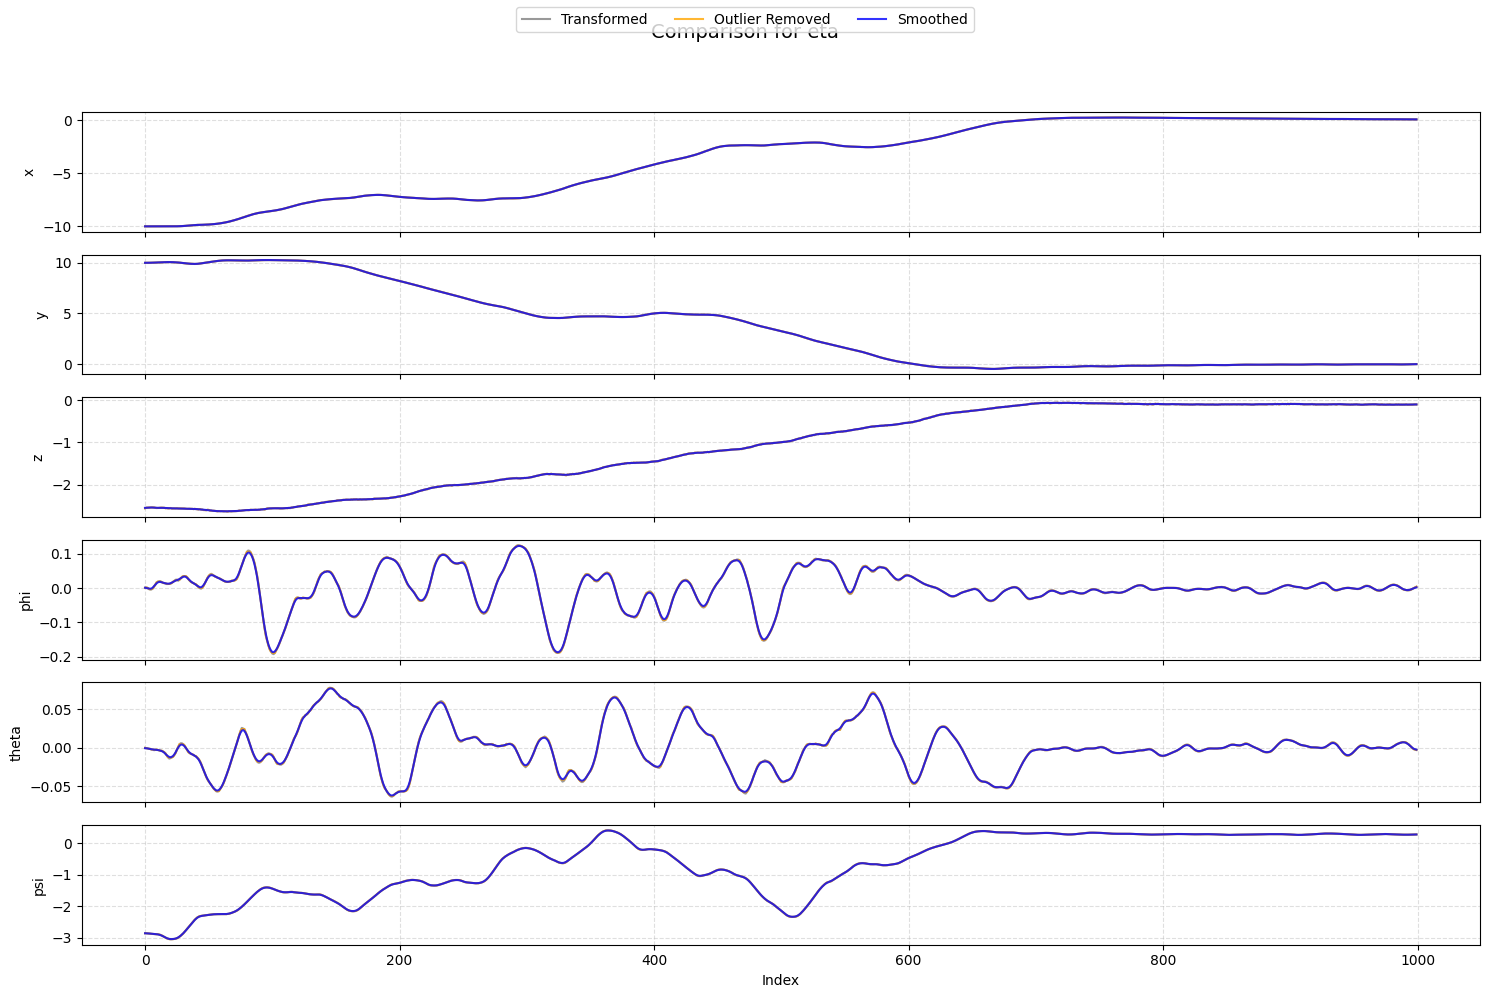

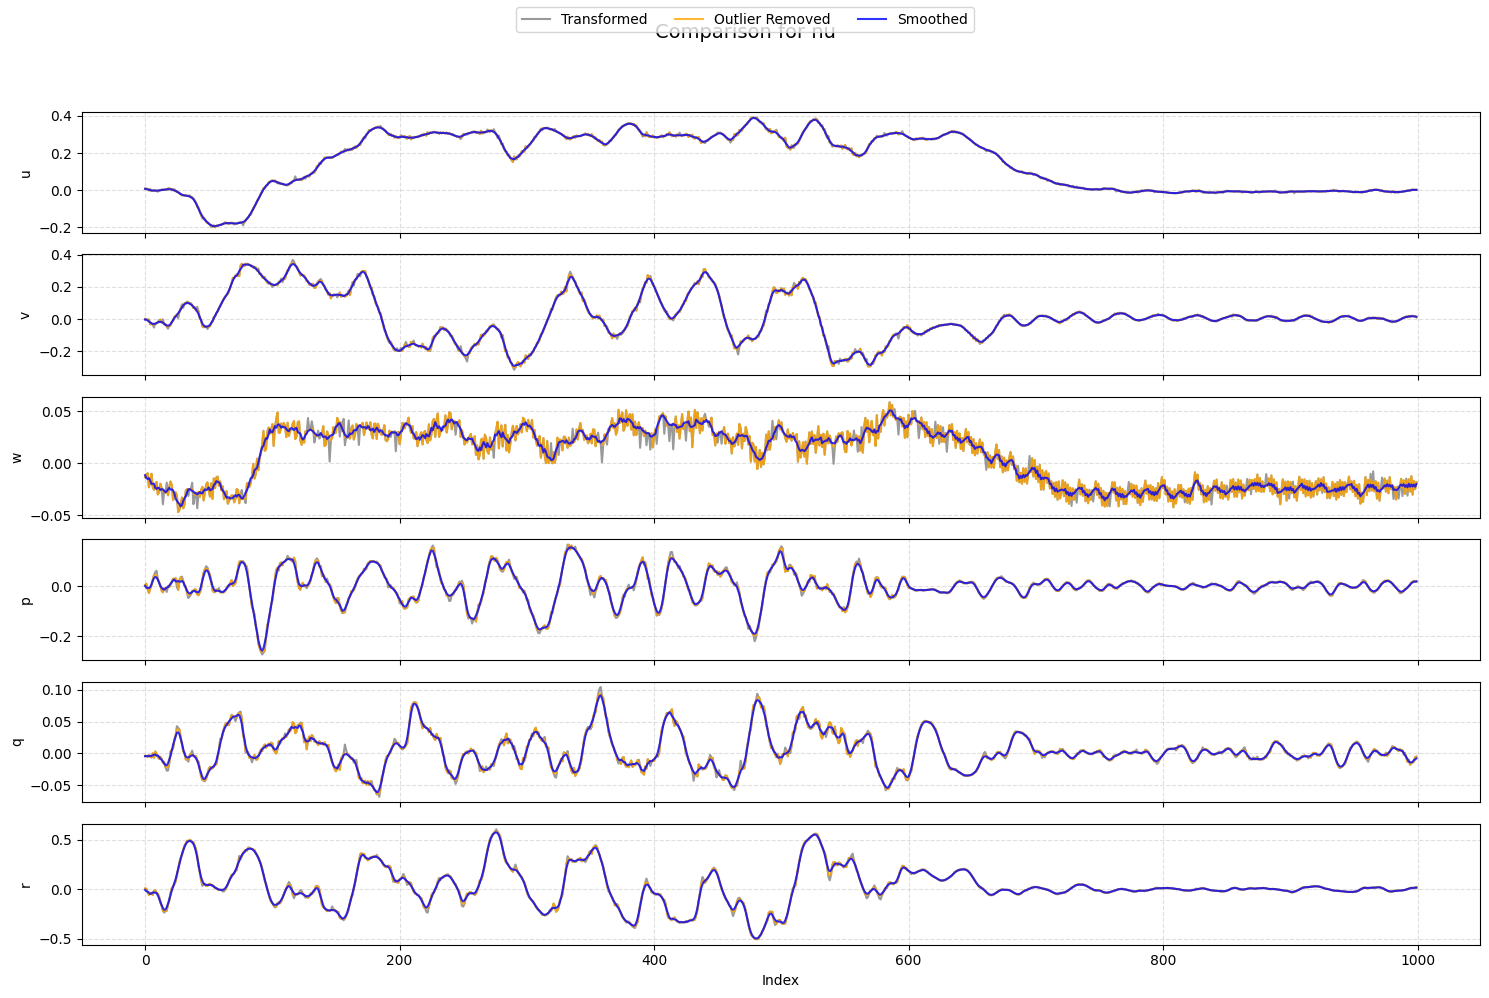

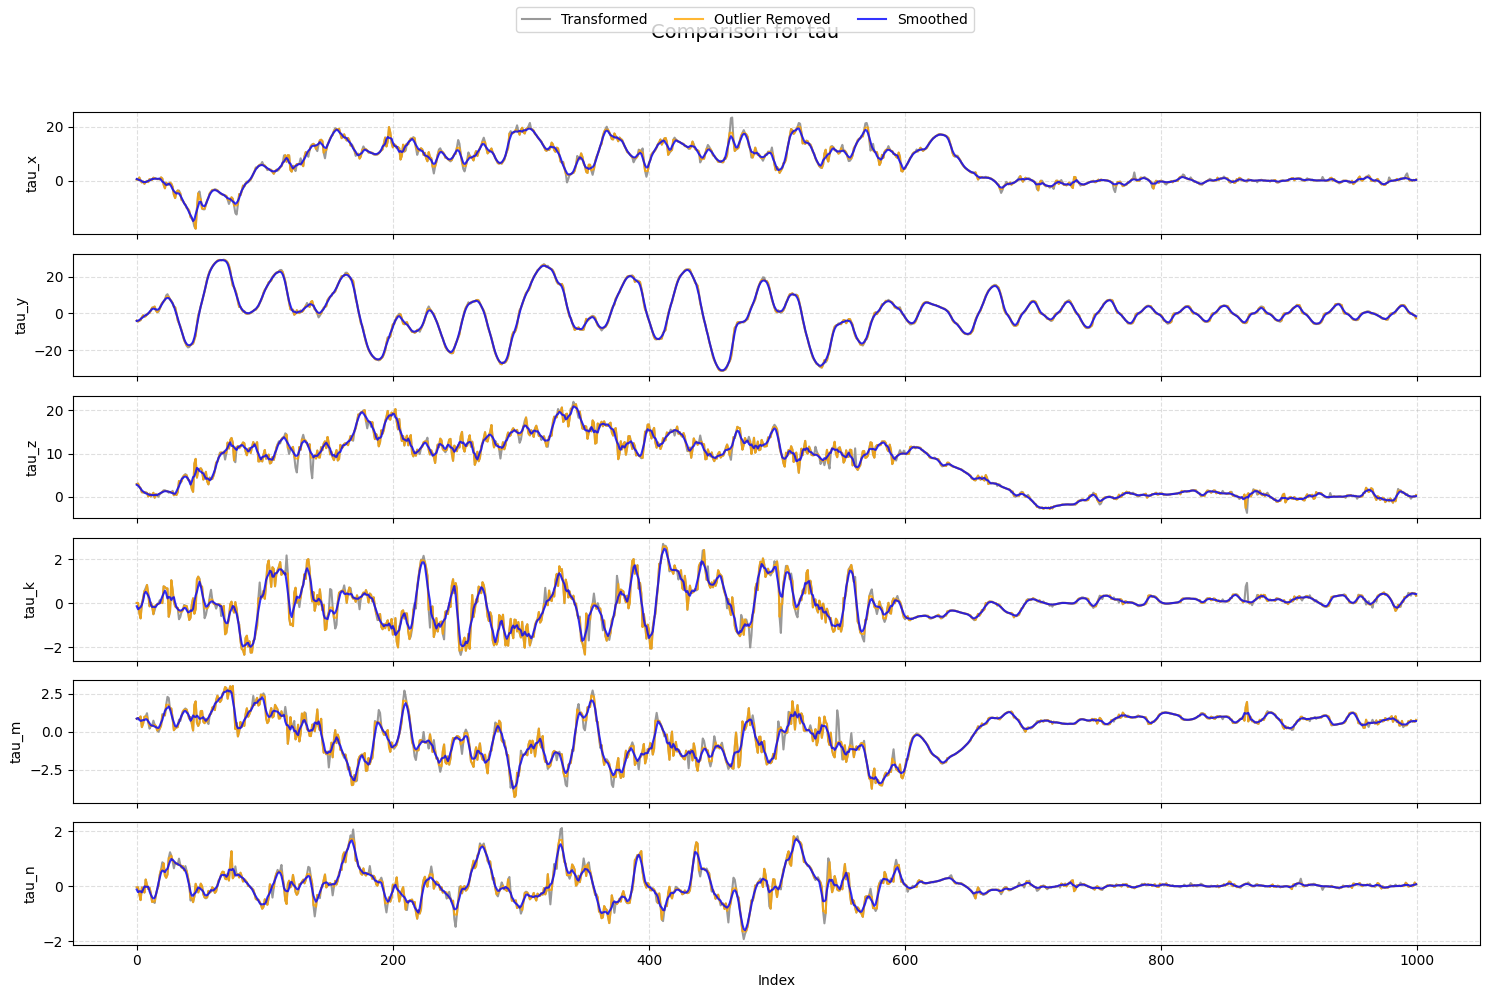

In [3]:
import matplotlib.pyplot as plt

file_key = list(transformed_data_list.keys())[0]
    
transformed_df = transformed_data_list[file_key]
outlier_removed_df = outlier_removed_data_list[file_key]
smoothed_df = smoothed_data_list[file_key]

dfs = [transformed_df, outlier_removed_df, smoothed_df]
labels = ['Transformed', 'Outlier Removed', 'Smoothed']
colors = ['gray', 'orange', 'blue']

eta_col = ['x', 'y', 'z', 'phi', 'theta', 'psi']
nu_col  = ['u', 'v', 'w', 'p', 'q', 'r']
tau_col = ['tau_x', 'tau_y', 'tau_z', 'tau_k', 'tau_m', 'tau_n']

metric_map = {
    'eta': eta_col,
    'nu': nu_col,
    'tau': tau_col
}

for metric, cols in metric_map.items():

    fig, axs = plt.subplots(
        nrows=6,
        ncols=1,
        figsize=(15, 10),
        sharex=True
    )

    for i, col in enumerate(cols):
        ax = axs[i]

        for df, label, color in zip(dfs, labels, colors):
            ax.plot(
                df.index,
                df[col],
                label=label,
                color=color,
                alpha=0.8,
                linewidth=1.5
            )

        ax.set_ylabel(col)
        ax.grid(True, linestyle='--', alpha=0.4)

    axs[-1].set_xlabel('Index')
    handles, labels_ = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='upper center', ncol=3)

    fig.suptitle(f'Comparison for {metric}', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


# DMDc 

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

import kmc.model as model
from kmc.utils import model_wrapper

smoothed_key_list = list(smoothed_data_list.keys())
train_set, test_set = train_test_split(smoothed_key_list, test_size=0.2, random_state=42)

train_data_list = {key: smoothed_data_list[key] for key in train_set}
test_data_list = {key: smoothed_data_list[key] for key in test_set}

# chek all sample in train and test set
print("Train set samples:", sum([data.shape[0] for data in train_data_list.values()]))
print("Test set samples:", sum([data.shape[0] for data in test_data_list.values()]))

# stack all data for scalers fitting
train_df = pd.concat(list(train_data_list.values()), ignore_index=True)
# state_df = train_df[eta_col].join(train_df[nu_col])
state_df = train_df[nu_col]
input_df = train_df[tau_col]

# Create scalers for state and input data
x_scaler = StandardScaler().fit(state_df.to_numpy())
u_scaler = StandardScaler().fit(input_df.to_numpy())

# transform data using the fitted scalers
scaled_train_data_list = {}
for key, df in train_data_list.items():
    state_data = df[nu_col]
    input_data = df[tau_col]
    scaled_state = x_scaler.transform(state_data.to_numpy())
    scaled_input = u_scaler.transform(input_data.to_numpy())
    scaled_df = pd.DataFrame(
        data = np.hstack((scaled_state, scaled_input)),
        columns = list(state_data.columns) + list(input_data.columns)
    )
    scaled_train_data_list[key] = scaled_df

# separate xk and uk and xk+1
data_for_model = []
for key, df in scaled_train_data_list.items():
    xk = df.iloc[:-1, :len(state_df.columns)].to_numpy()
    uk = df.iloc[:-1, len(state_df.columns):].to_numpy()
    xk1 = df.iloc[1:, :len(state_df.columns)].to_numpy()
    data_for_model.append((xk, uk, xk1))

# concat data to single arrays
# Xk : shape (N_samples * N_trajectories, N_state)
# Uk : shape (N_samples * N_trajectories, N_input)
# Xk1: shape (N_samples * N_trajectories, N_state)

Xk = np.concatenate([data[0] for data in data_for_model], axis=0)
Uk = np.concatenate([data[1] for data in data_for_model], axis=0)
Xk1 = np.concatenate([data[2] for data in data_for_model], axis=0)

print(f"Xk shape: {Xk.shape}")
print(f"Uk shape: {Uk.shape}")
print(f"Xk1 shape: {Xk1.shape}")

# check NaN values
assert not np.isnan(Xk).any(), "NaN values found in Xk"
assert not np.isnan(Uk).any(), "NaN values found in Uk"
assert not np.isnan(Xk1).any(), "NaN values found in Xk1"

# Initialize and fit DMDc model
dmdc_model = model.DMDc()
dmdc_model.fit(Xk, Xk1, Uk)

# wrap the model with scalers
wrapped_dmdc_model = model_wrapper.SklearnModelWrapper(
    model=dmdc_model,
    scaler_x=x_scaler,
    scaler_u=u_scaler)

/home/tanbjs/kmc/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/tanbjs/kmc/.venv/lib/python3.10/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
/home/tanbjs/kmc/.venv/lib/python3.10/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


Train set samples: 23994
Test set samples: 5997
Xk shape: (23970, 6)
Uk shape: (23970, 6)
Xk1 shape: (23970, 6)


Max Eigenvalue Magnitude: 0.98030290760821814366


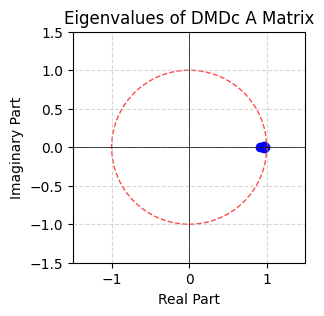

In [5]:
# Get eigenvalues of the A matrix
eigenvalues = np.linalg.eigvals(dmdc_model.A)

# check max eigenvalue magnitude with high precision
max_eigenvalue_magnitude = np.max(np.abs(eigenvalues))
print(f"Max Eigenvalue Magnitude: {max_eigenvalue_magnitude:.20f}") 

# Plot eigenvalues
plt.figure(figsize=(3,3))
plt.scatter(eigenvalues.real, eigenvalues.imag, color='blue', marker='o')
plt.title('Eigenvalues of DMDc A Matrix')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
circle = plt.Circle((0, 0), 1, color='red', fill=False, linestyle='--', alpha=0.7)
plt.gca().add_artist(circle)
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.show()

# predict on test set
test_results = {}
for key, df in test_data_list.items():
    state_data = df[nu_col]
    input_data = df[tau_col]
    xk = state_data.iloc[:-1]
    uk = input_data.iloc[:-1]
    xk1_true = state_data.iloc[1:]
    xk1_pred = wrapped_dmdc_model.predict(None, model_input={'x': xk, 'u': uk})
    test_results[key] = {
        'xk': xk,
        'uk': uk,
        'xk1_true': xk1_true,
        'xk1_pred': xk1_pred
    }

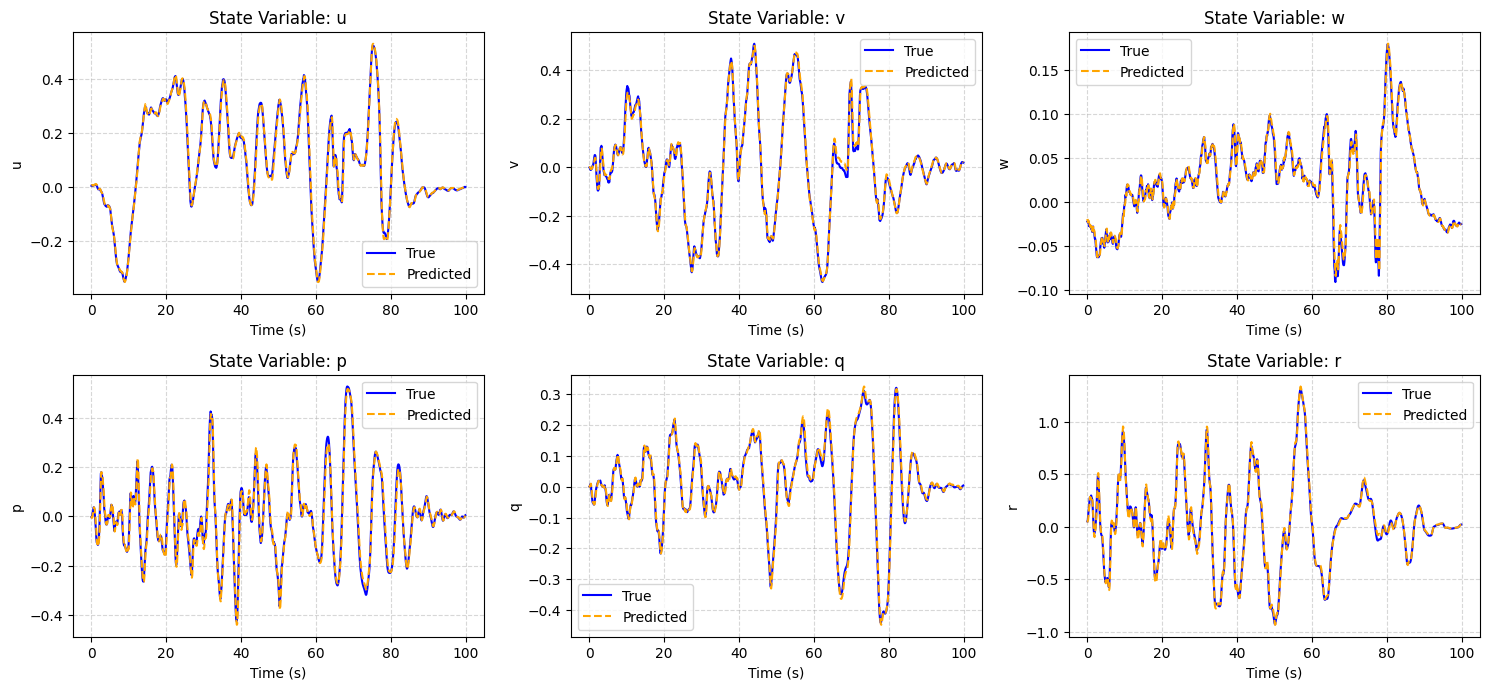

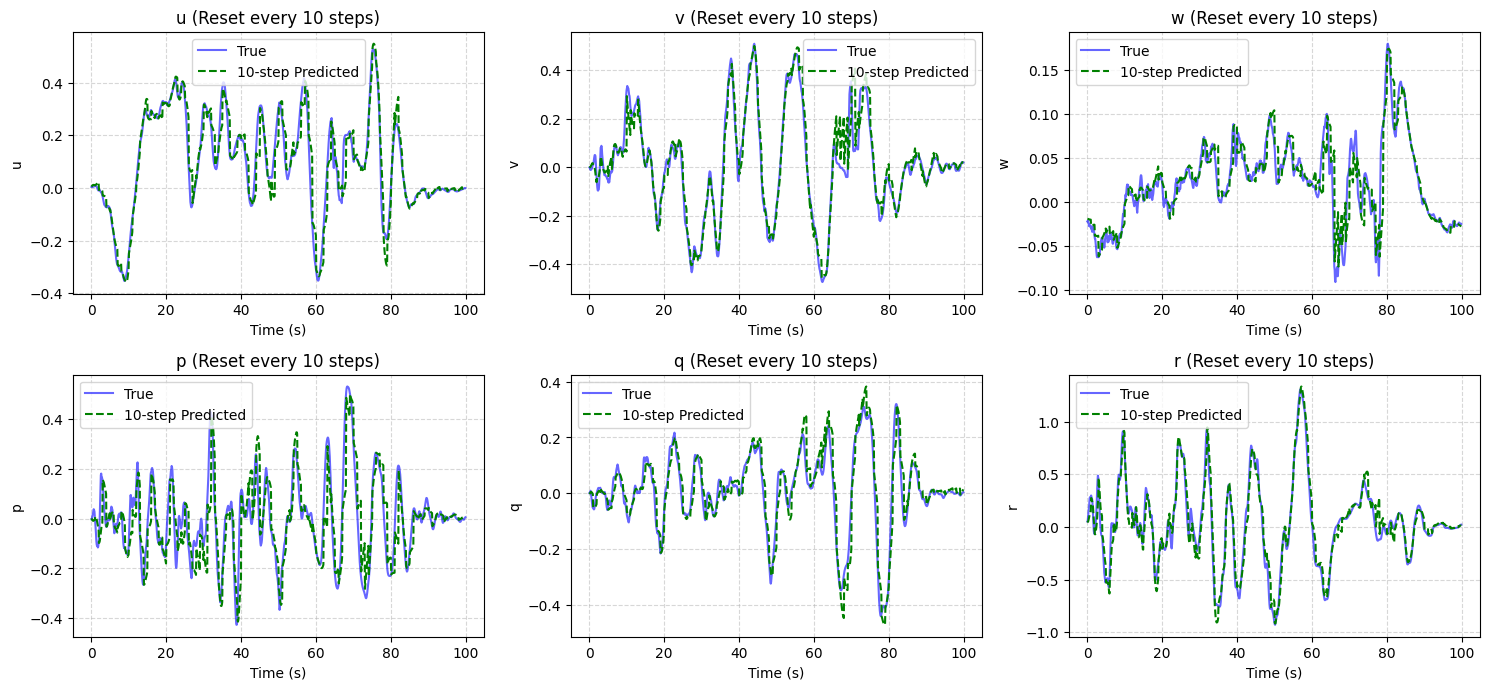

In [6]:
# plot one-step true vs predicted for test set only selected files
selected_test_keys = list(test_results.keys())[1]
result = test_results[selected_test_keys]
time_index = test_data_list[selected_test_keys]['time'].iloc[1:]
plt.figure(figsize=(15, 10))
state_variables = state_df.columns.tolist()
for i, var in enumerate(state_variables):
    plt.subplot(3, 3, i+1)
    plt.plot(time_index, result['xk1_true'][var], label='True', color='blue')
    plt.plot(time_index, result['xk1_pred'][:, i], label='Predicted', color='orange', linestyle='--')
    plt.title(f'State Variable: {var}')
    plt.xlabel('Time (s)')
    plt.ylabel(var)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- Configuration ---
N_horizon = 10

# --- Plotting Code ---
time_index = test_data_list[selected_test_keys]['time'].iloc[1:]
plt.figure(figsize=(15, 10))
state_variables = state_df.columns.tolist()
true_states_matrix = result['xk1_true'].to_numpy()

for i, var in enumerate(state_variables):
    plt.subplot(3, 3, i+1)
    
    xk_current = result['xk'].iloc[0].to_numpy().reshape(1, -1)
    uk_series = result['uk'].to_numpy()
    n_step_preds = []
    
    for step in range(len(uk_series)):
        uk_current = uk_series[step].reshape(1, -1)
        xk_next = wrapped_dmdc_model.predict(None, model_input={'x': xk_current, 'u': uk_current})
        n_step_preds.append(xk_next.flatten())
        if (step + 1) % N_horizon == 0:
            xk_current = true_states_matrix[step].reshape(1, -1)
        else:
            xk_current = xk_next

    n_step_preds = np.array(n_step_preds)
    
    # Plotting
    plot_len = min(len(time_index), len(n_step_preds))
    plt.plot(time_index[:plot_len], result['xk1_true'][var].iloc[:plot_len], label='True', color='blue', alpha=0.6)
    plt.plot(time_index[:plot_len], n_step_preds[:plot_len, i], label=f'{N_horizon}-step Predicted', color='green', linestyle='--')
    plt.title(f'{var} (Reset every {N_horizon} steps)')
    plt.xlabel('Time (s)')
    plt.ylabel(var)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# EDMDc 

# Deep Koopman with Control 